# Classification Model Comparison

This notebook compares classification models for predicting `HealthImpactClass`, a categorical health outcome variable.

The models include:
- Multiclass Logistic Regression
- Lasso-Regularized Logistic Regression
- K-Nearest Neighbors (KNN)

We use stratified 10-fold cross-validation because the target classes are imbalanced.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")

## Load Dataset

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "air_quality_health_impact_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


## Define Predictors and Target

The target variable is `HealthImpactClass`.

We exclude:
- `RecordID`, because it is only an identifier.
- `HealthImpactScore`, because it is closely related to the class label and could cause target leakage.
- Health-related case counts, because this analysis focuses on whether environmental conditions predict the health impact class.

In [3]:
predictors = [
    "AQI",
    "PM10",
    "PM2_5",
    "NO2",
    "SO2",
    "O3",
    "Temperature",
    "Humidity",
    "WindSpeed"
]

X = df[predictors]
y = df["HealthImpactClass"].astype(int)

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (5811, 9)
Target shape: (5811,)


## Class Distribution

Before modeling, we examine the number of records in each class.

How to read the output:
- Each number represents one `HealthImpactClass`.
- A larger count means that more records belong to that class.
- If one class has many more records than the others, the dataset is imbalanced.

In [4]:
class_counts = y.value_counts().sort_index()

class_counts

HealthImpactClass
0    4808
1     579
2     273
3      95
4      56
Name: count, dtype: int64

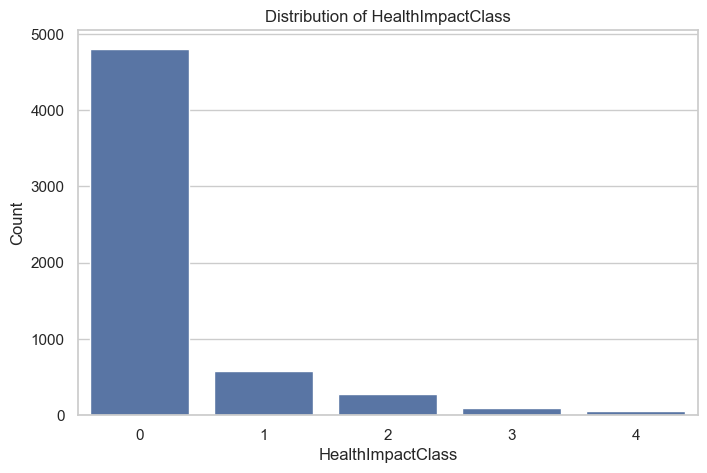

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y, order=sorted(y.unique()))
plt.title("Distribution of HealthImpactClass")
plt.xlabel("HealthImpactClass")
plt.ylabel("Count")
plt.show()

The target classes are imbalanced, with most records belonging to class `0`. For this reason, accuracy alone may be misleading. We will also use balanced accuracy, macro F1-score, classification reports, and confusion matrices.

## Train/Test Split and Cross-Validation

We reserve 20% of the data as a final test set. We use stratification so that the class proportions remain similar in the training and testing sets.

Within the training set, we use stratified 10-fold cross-validation.

How to read the metrics:
- `Accuracy` is the percentage of predictions that are correct.
- `Balanced accuracy` gives equal importance to each class. This is useful when classes are imbalanced.
- `Macro F1-score` calculates the F1-score for each class and gives each class equal weight. Higher values are better.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro"
}

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 4648
Testing rows: 1163


In [7]:
def cross_validation_summary(model_name, model):
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        "Model": model_name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Mean CV Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "Mean CV Macro F1": scores["test_f1_macro"].mean()
    }


def test_summary(model_name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return {
        "Model": model_name,
        "Test Accuracy": accuracy_score(y_test, predictions),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Test Macro F1": f1_score(y_test, predictions, average="macro")
    }

## Multiclass Logistic Regression Baseline

Logistic Regression provides a baseline classification model. We use balanced class weights so that smaller classes receive more attention during training.

In [8]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

logistic_cv = cross_validation_summary(
    "Logistic Regression",
    logistic_model
)

pd.DataFrame([logistic_cv])

,Model,Mean CV Accuracy,Mean CV Balanced Accuracy,Mean CV Macro F1
0,Logistic Regression,0.443194,0.364615,0.294446


## Lasso-Regularized Logistic Regression

Lasso regularization can reduce the influence of weaker predictors. In Logistic Regression, the regularization strength is controlled by `C`.

How to read `C`:
- Smaller `C` values apply stronger regularization.
- Larger `C` values apply weaker regularization.
- The best `C` value is selected using macro F1-score because the classes are imbalanced.

In [9]:
lasso_logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ovr", OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            l1_ratio=1,
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        )
    ))
])

lasso_logistic_search = GridSearchCV(
    estimator=lasso_logistic_pipeline,
    param_grid={
        "ovr__estimator__C": [0.01, 0.1, 1]
    },
    scoring="f1_macro",
    cv=cv,
    n_jobs=1
)

lasso_logistic_search.fit(X_train, y_train)

print("Best C:", lasso_logistic_search.best_params_["ovr__estimator__C"])
print("Best CV Macro F1:", lasso_logistic_search.best_score_)

Best C: 1
Best CV Macro F1: 0.28718676944388244


In [11]:
lasso_logistic_results = pd.DataFrame({
    "C": lasso_logistic_search.cv_results_["param_ovr__estimator__C"].astype(float),
    "Mean CV Macro F1": lasso_logistic_search.cv_results_["mean_test_score"]
}).sort_values("C")

lasso_logistic_results

,C,Mean CV Macro F1
0,0.01,0.269807
1,0.10,0.283976
2,1.00,0.287187


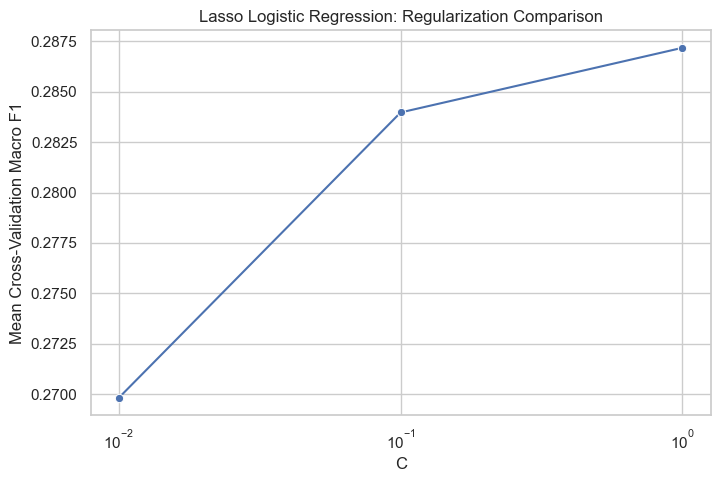

In [12]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=lasso_logistic_results, x="C", y="Mean CV Macro F1", marker="o")
plt.xscale("log")
plt.title("Lasso Logistic Regression: Regularization Comparison")
plt.xlabel("C")
plt.ylabel("Mean Cross-Validation Macro F1")
plt.show()

## K-Nearest Neighbors

KNN classifies each record based on nearby records with similar predictor values. Scaling is important because the environmental predictors use different units.

We compare several values of `k`, the number of neighbors:
- Smaller values can create a more flexible model.
- Larger values create smoother decision boundaries.
- The best `k` value is selected using macro F1-score.

In [13]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid={
        "knn__n_neighbors": [3, 5, 7, 11, 15, 21],
        "knn__weights": ["uniform", "distance"]
    },
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

print("Best parameters:", knn_search.best_params_)
print("Best CV Macro F1:", knn_search.best_score_)

Best parameters: {'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best CV Macro F1: 0.3518199174515096


In [14]:
knn_results = pd.DataFrame({
    "Neighbors": knn_search.cv_results_["param_knn__n_neighbors"].astype(int),
    "Weights": knn_search.cv_results_["param_knn__weights"],
    "Mean CV Macro F1": knn_search.cv_results_["mean_test_score"]
}).sort_values(["Weights", "Neighbors"])

knn_results

,Neighbors,Weights,Mean CV Macro F1
1,3,distance,0.351820
3,5,distance,0.339418
5,7,distance,0.318120
7,11,distance,0.294403
9,15,distance,0.272079
11,21,distance,0.245415
0,3,uniform,0.321109
2,5,uniform,0.291039
4,7,uniform,0.286034
6,11,uniform,0.272669


## Final Model Comparison

This section compares the final performance of each model on the held-out test set.

Because the classes are imbalanced, balanced accuracy and macro F1-score are more informative than accuracy alone.

In [15]:
best_models = {
    "Logistic Regression": logistic_model,
    "Lasso Logistic Regression": lasso_logistic_search.best_estimator_,
    "K-Nearest Neighbors": knn_search.best_estimator_
}

comparison_results = pd.DataFrame([
    test_summary(model_name, model)
    for model_name, model in best_models.items()
]).sort_values("Test Macro F1", ascending=False)

comparison_results

,Model,Test Accuracy,Test Balanced Accuracy,Test Macro F1
2,K-Nearest Neighbors,0.844368,0.301072,0.310798
0,Logistic Regression,0.445400,0.390115,0.303454
1,Lasso Logistic Regression,0.684437,0.322849,0.286937


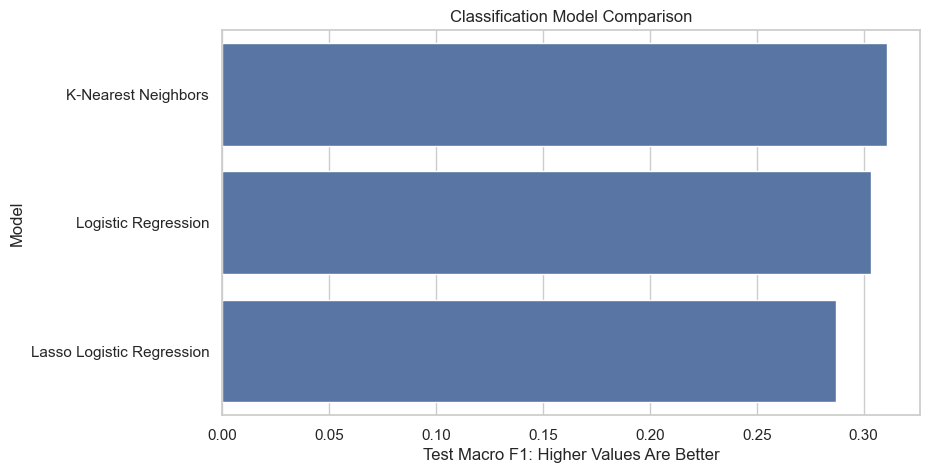

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=comparison_results,
    x="Test Macro F1",
    y="Model"
)
plt.title("Classification Model Comparison")
plt.xlabel("Test Macro F1: Higher Values Are Better")
plt.ylabel("Model")
plt.show()

## Classification Report and Confusion Matrix

This section examines the best-performing model in more detail.

How to read the classification report:
- `Precision` measures how often predictions for a class are correct.
- `Recall` measures how often the model identifies records that belong to a class.
- `F1-score` balances precision and recall.
- `Support` shows the number of test records in each class.

How to read the confusion matrix:
- Rows represent actual classes.
- Columns represent predicted classes.
- Values on the diagonal represent correct predictions.

In [17]:
best_model_name = comparison_results.iloc[0]["Model"]
best_model = best_models[best_model_name]

best_model.fit(X_train, y_train)
best_predictions = best_model.predict(X_test)

print("Best model:", best_model_name)
print()
print(classification_report(y_test, best_predictions, zero_division=0))

Best model: K-Nearest Neighbors

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       962
           1       0.41      0.26      0.32       116
           2       0.33      0.27      0.30        55
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00        11

    accuracy                           0.84      1163
   macro avg       0.33      0.30      0.31      1163
weighted avg       0.80      0.84      0.82      1163



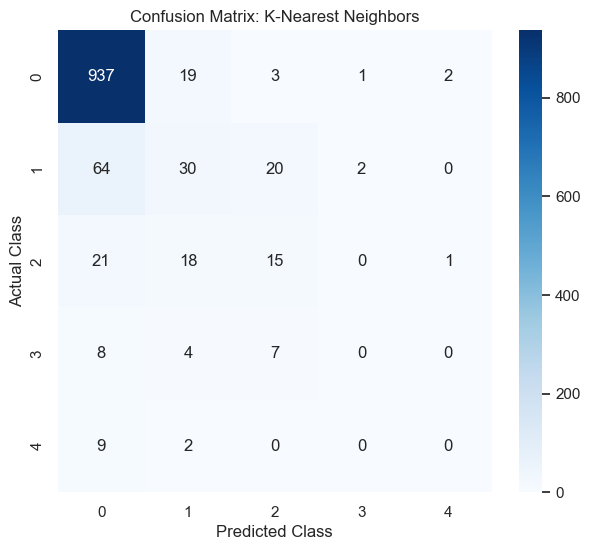

In [18]:
matrix = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()